# 🤖 NEXORA · Entrenamiento del Modelo de IA — Predicción de Abandono (Churn)
### Parcial 3 — ITY1101 Gestión de Datos para IA · DUOC UC
**Equipo:** Esteban Gamboa · Julio Llauri · Joel Sangster

Este notebook recorre el flujo supervisado completo para predecir el **abandono
de suscriptores** de NEXORA, reutilizando los módulos productivos de `src/`:
`preprocesamiento`, `visualizaciones` y `entrenamiento`.

**Flujo:** calidad de datos → análisis univariado/bivariado → preprocesamiento →
entrenamiento de varios algoritmos → ajuste de hiperparámetros → métricas
(matriz de confusión, ROC, **Gini**) → persistencia del modelo.

In [1]:
import sys
from pathlib import Path

# Permite importar los módulos de src/ desde el notebook
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import preprocesamiento as prep
import visualizaciones as viz
import entrenamiento as ent

print("Módulos cargados desde:", RAIZ / "src")

Módulos cargados desde: C:\BlackBox\GitHub\EntrenamientoAI\nexora-ml\src


## 📂 Paso 1 — Carga y calidad de datos

In [2]:
df = prep.cargar_datos()
calidad = prep.analisis_calidad(df)
print(f"Filas: {calidad['n_filas']} | Columnas: {calidad['n_columnas']}")
print(f"Nulos: {calidad['total_nulos']} | Duplicados: {calidad['duplicados']}")
print(f"Balance objetivo (%): {calidad['balance_objetivo_pct']}")
print(f"Ratio de desbalance: {calidad['ratio_desbalance']} : 1")
df.head()

Filas: 500 | Columnas: 7
Nulos: 0 | Duplicados: 0
Balance objetivo (%): {0: 74.6, 1: 25.4}
Ratio de desbalance: 2.94 : 1


,edad,anos_cliente,uso_datos_gb,llamadas_mes,reclamos,plan_premium,abandona
0,56,7,3.3,80,4,0,0
1,69,5,4.5,71,4,1,0
2,46,6,14.4,20,0,1,0
3,32,7,10.1,17,0,1,0
4,60,3,15.2,93,1,0,0


In [3]:
# Estadística descriptiva: media, mediana, percentiles
calidad['descriptivas']

,count,mean,std,min,25%,50%,75%,max,mediana
edad,500.0,44.220,15.036,18.0,32.000,45.0,57.0,69.0,45.0
anos_cliente,500.0,4.868,2.577,1.0,3.000,5.0,7.0,9.0,5.0
uso_datos_gb,500.0,10.391,5.710,0.5,5.475,10.6,15.5,20.0,10.6
llamadas_mes,500.0,48.702,28.880,0.0,24.000,47.0,74.0,99.0,47.0
reclamos,500.0,2.102,1.427,0.0,1.000,2.0,3.0,4.0,2.0
plan_premium,500.0,0.386,0.487,0.0,0.000,0.0,1.0,1.0,0.0
abandona,500.0,0.254,0.436,0.0,0.000,0.0,1.0,1.0,0.0


## 🔍 Paso 2 — Análisis exploratorio (univariado, bivariado, correlación)
Generamos las figuras y las mostramos en línea.

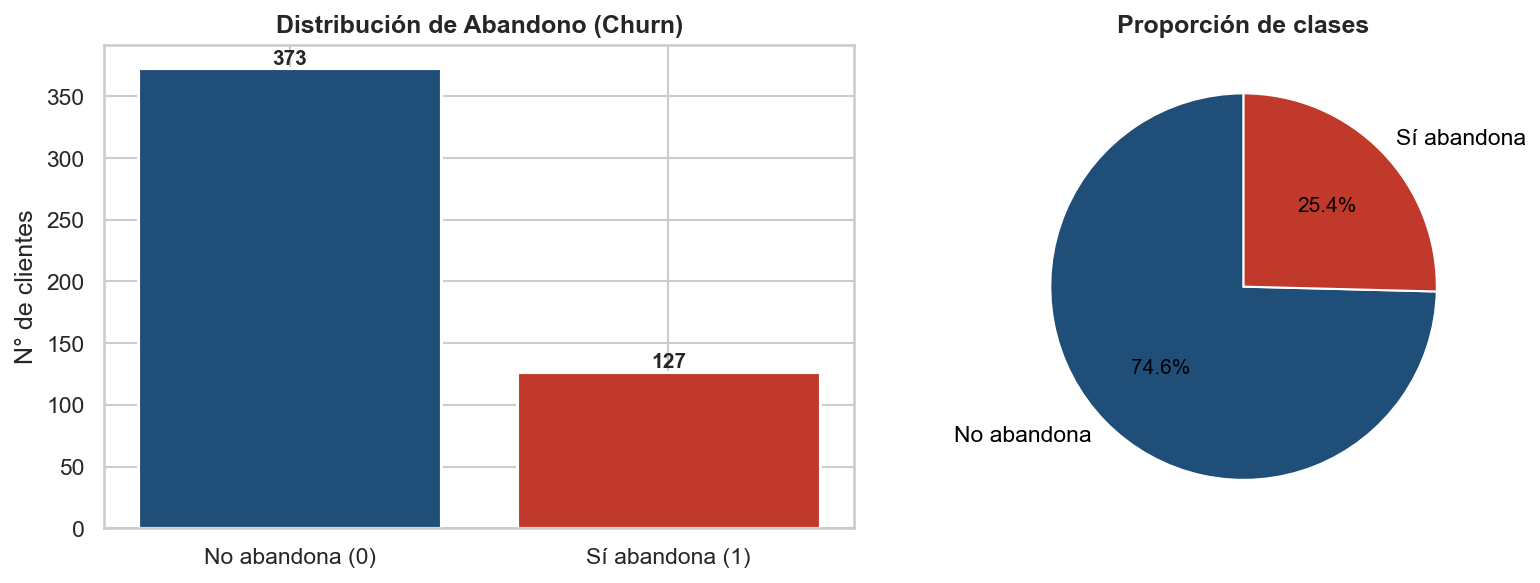

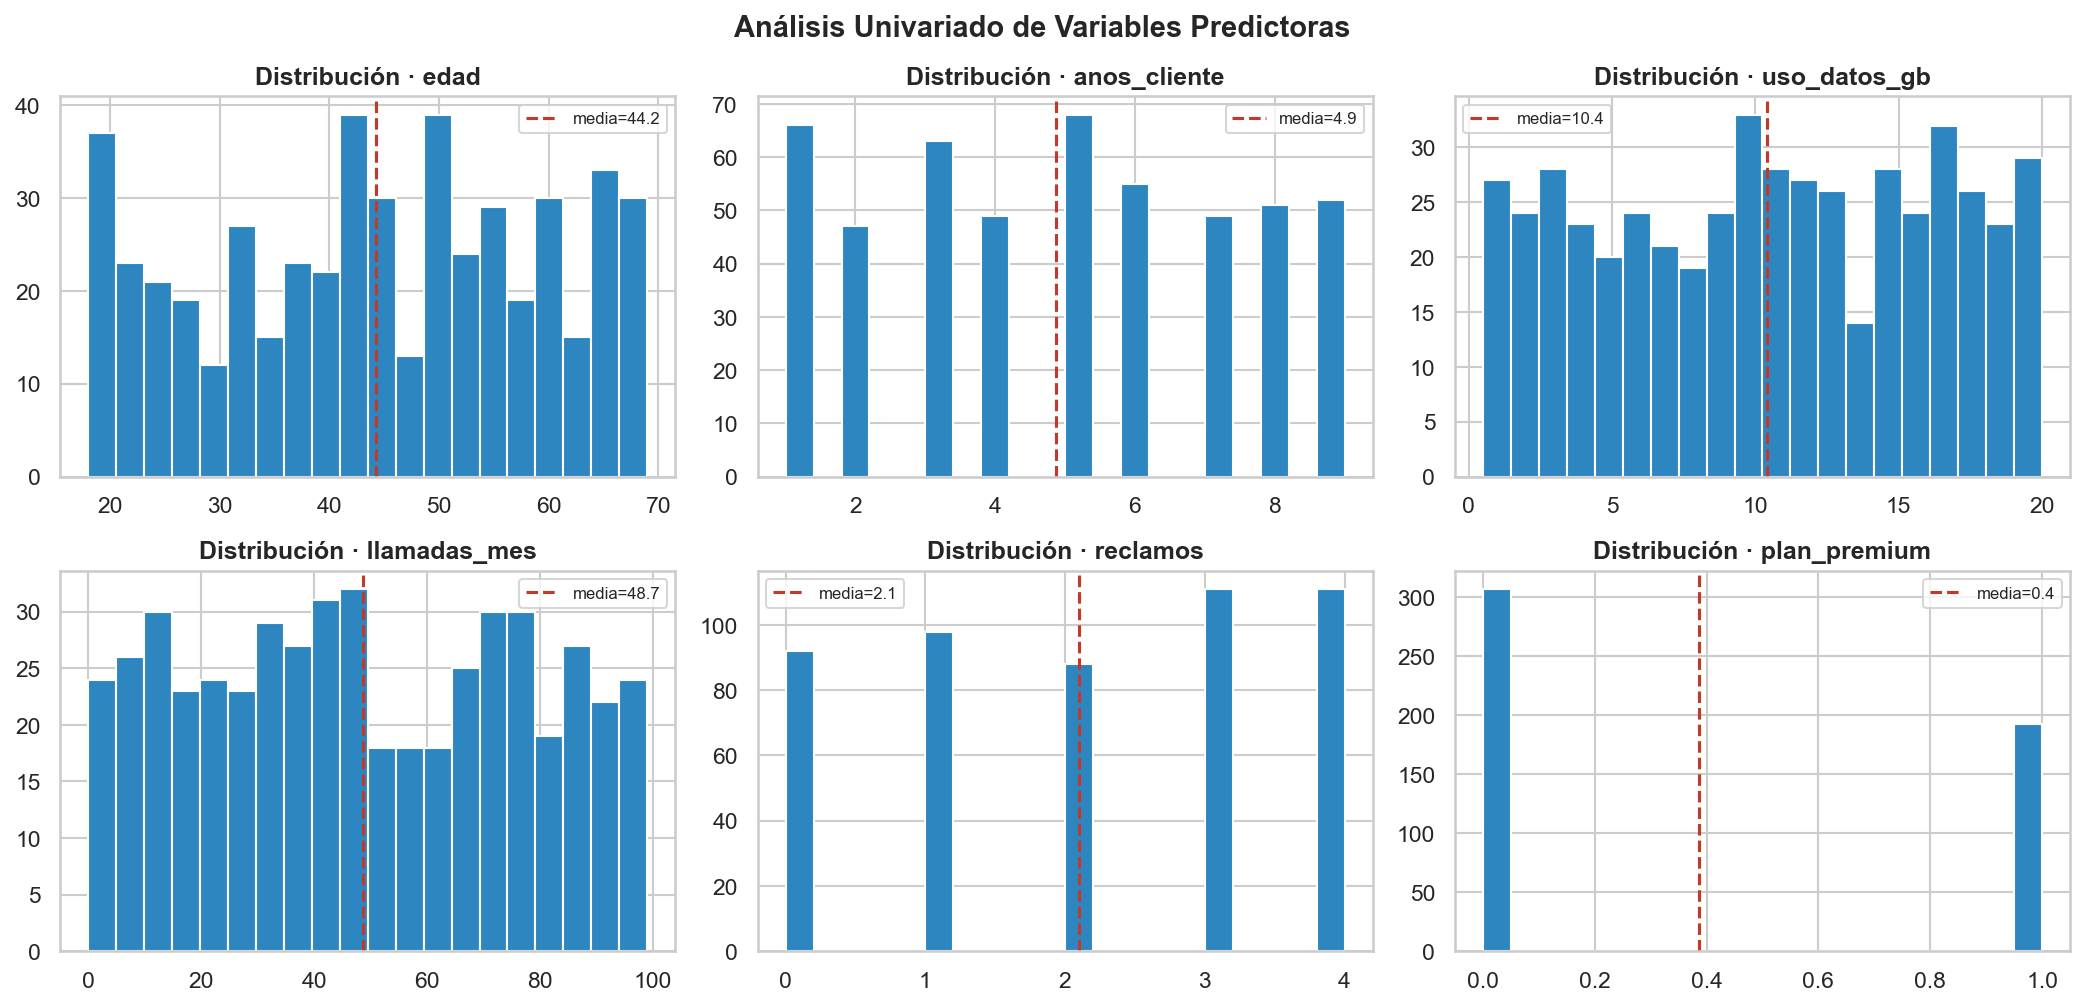

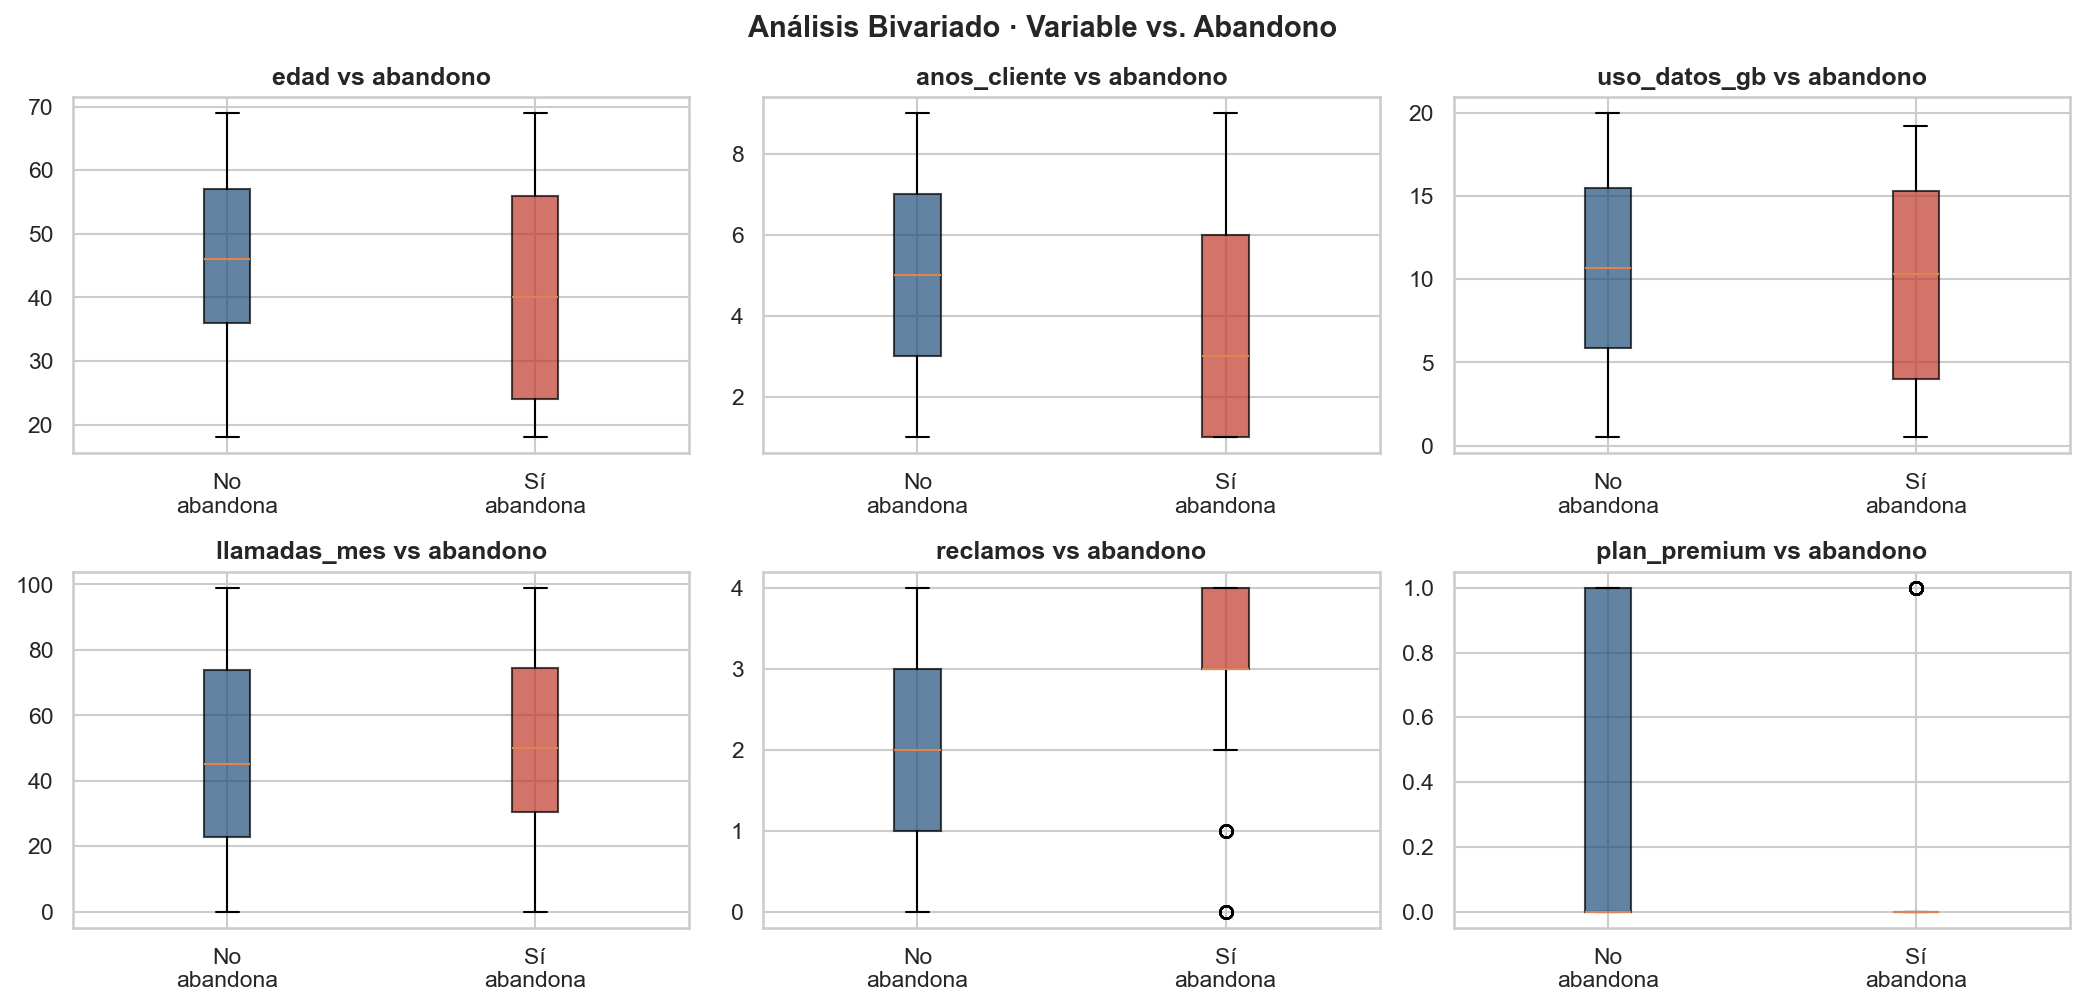

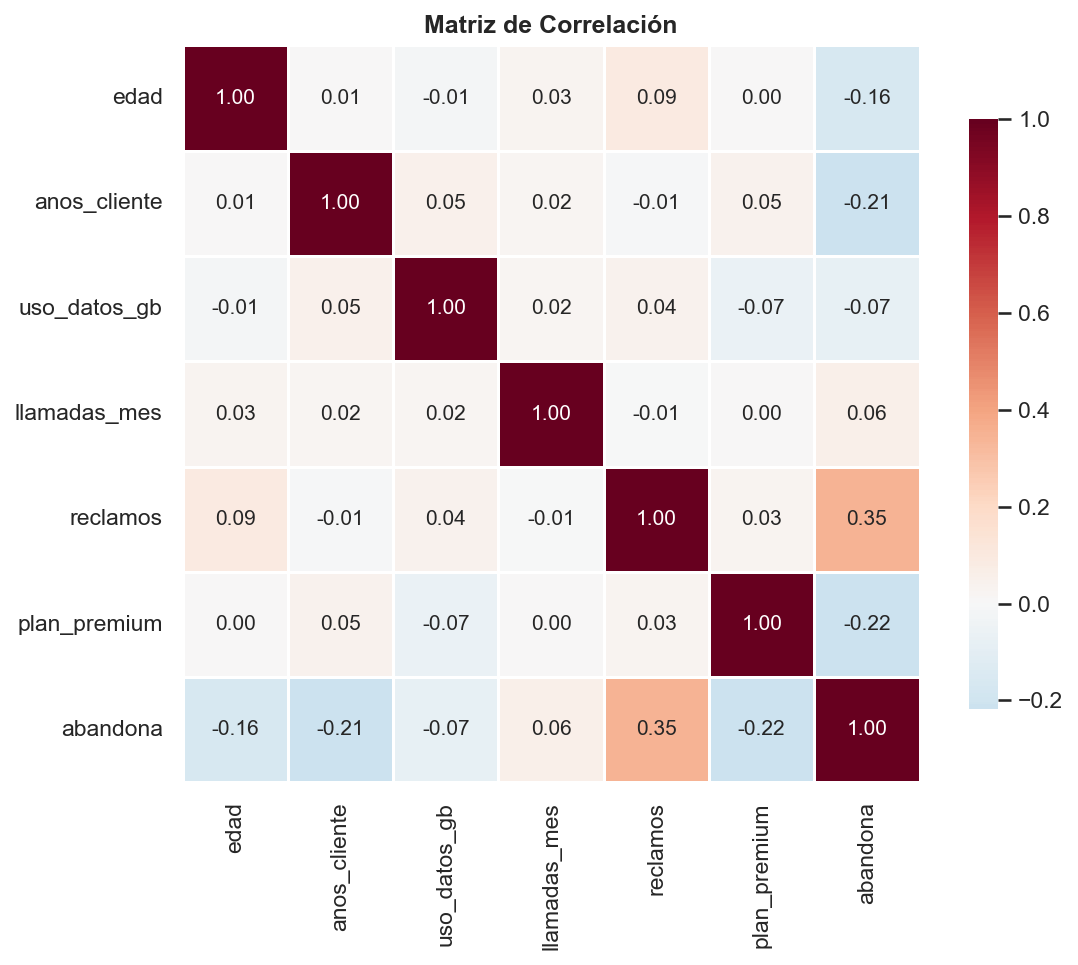

In [4]:
from IPython.display import Image, display

viz.grafico_balance_objetivo(df)
viz.grafico_univariado(df)
viz.grafico_bivariado(df)
viz.grafico_correlacion(df)

for n in ["01_balance_objetivo", "02_univariado", "03_bivariado", "04_correlacion"]:
    display(Image(filename=str(viz.DIR_FIG / f"{n}.png")))

**Lectura:** el dataset está desbalanceado (~75/25). En el bivariado, los clientes
que abandonan muestran más reclamos y menor antigüedad. No hay multicolinealidad
severa en la matriz de correlación.

## ✂️ Paso 3 — Partición estratificada y escalado

In [5]:
datos = prep.preparar_datos(df, random_state=42)
print(f"Train: {len(datos['X_train'])} | Test: {len(datos['X_test'])} (80/20 estratificado)")
print("Variables:", datos['columnas'])

Train: 400 | Test: 100 (80/20 estratificado)
Variables: ['edad', 'anos_cliente', 'uso_datos_gb', 'llamadas_mes', 'reclamos', 'plan_premium']


## 🏋️ Paso 4 — Entrenamiento, ajuste y evaluación
Ejecutamos el pipeline de entrenamiento completo (`entrenamiento.main()`), que
entrena 4 algoritmos, optimiza Random Forest con `GridSearchCV`, calcula todas las
métricas, genera las figuras de evaluación y persiste el mejor modelo.

In [6]:
resumen = ent.main()
print("Modelo seleccionado:", resumen['modelo_seleccionado'])

2026-06-19 10:23:47,158 - INFO - ======================================================================


2026-06-19 10:23:47,159 - INFO - NEXORA · Inicio del entrenamiento del modelo de IA (churn)


2026-06-19 10:23:47,171 - INFO - Dataset cargado: 500 filas x 7 columnas


2026-06-19 10:23:47,172 - INFO - Nulos: 0 | Duplicados: 0


2026-06-19 10:23:47,172 - INFO - Balance objetivo (%): {0: 74.6, 1: 25.4} | Ratio desbalance: 2.94:1


...

2026-06-19 10:24:28,606 - INFO - Métricas exportadas a C:\BlackBox\GitHub\EntrenamientoAI\nexora-ml\reports\metricas.json


2026-06-19 10:24:28,616 - INFO - Reporte de clasificación del modelo seleccionado:
              precision    recall  f1-score   support

 No abandona       0.91      0.80      0.85        75
 Sí abandona       0.56      0.76      0.64        25

    accuracy                           0.79       100
   macro avg       0.73      0.78      0.75       100
weighted avg       0.82      0.79      0.80       100



2026-06-19 10:24:28,616 - INFO - Entrenamiento finalizado en 41.453s


2026-06-19 10:24:28,617 - INFO - ======================================================================


Modelo seleccionado: Random Forest (optimizado)


In [7]:
import pandas as pd
tabla = pd.DataFrame(resumen['metricas_por_modelo']).T[
    ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'gini']
]
tabla

,accuracy,precision,recall,f1,roc_auc,gini
Regresión Logística,0.78,0.5484,0.68,0.6071,0.8176,0.6352
Árbol de Decisión,0.76,0.5143,0.72,0.6,0.7869,0.5739
Random Forest,0.8,0.5862,0.68,0.6296,0.8651,0.7301
Gradient Boosting,0.8,0.6471,0.44,0.5238,0.8443,0.6885
Random Forest (optimizado),0.79,0.5588,0.76,0.6441,0.8773,0.7547


## 📏 Paso 5 — Matriz de confusión, Curva ROC y métricas

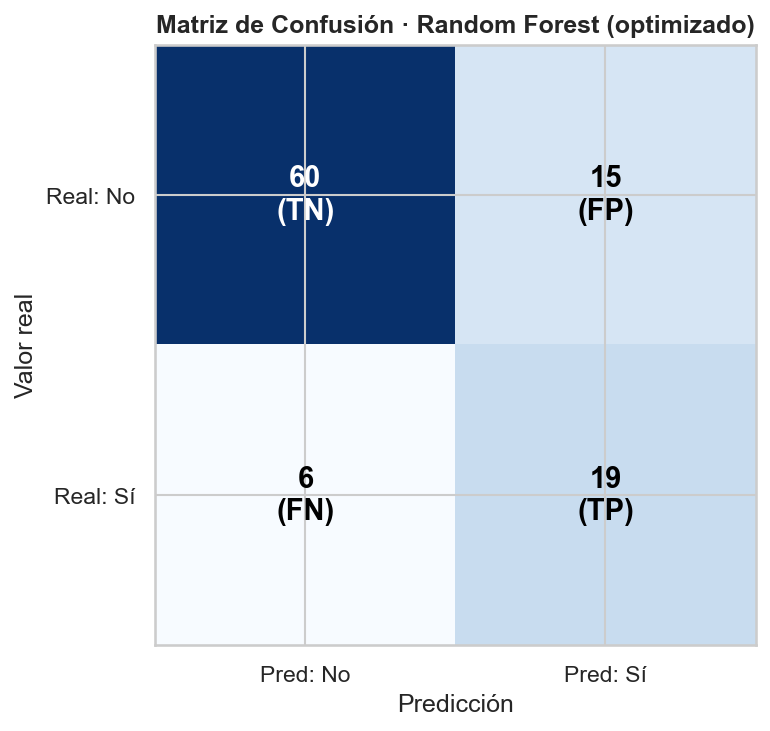

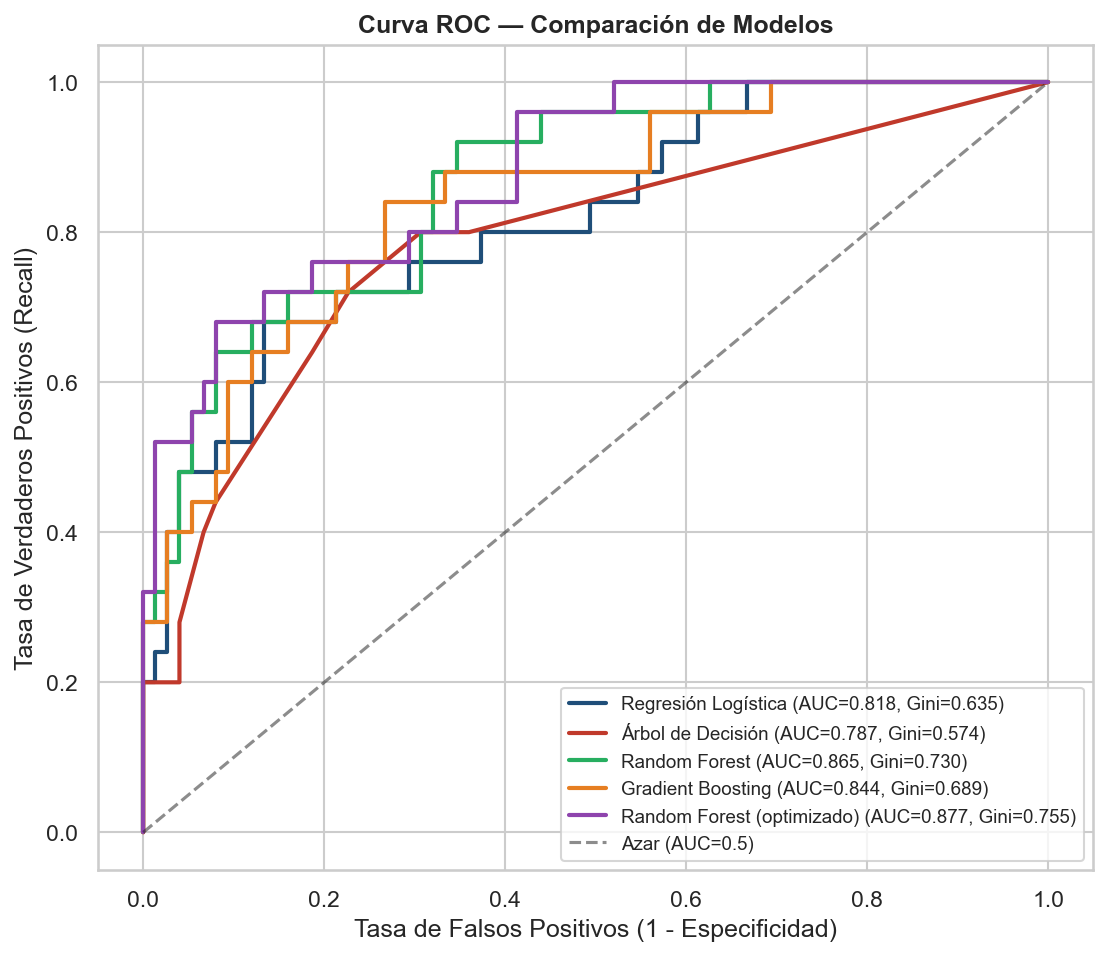

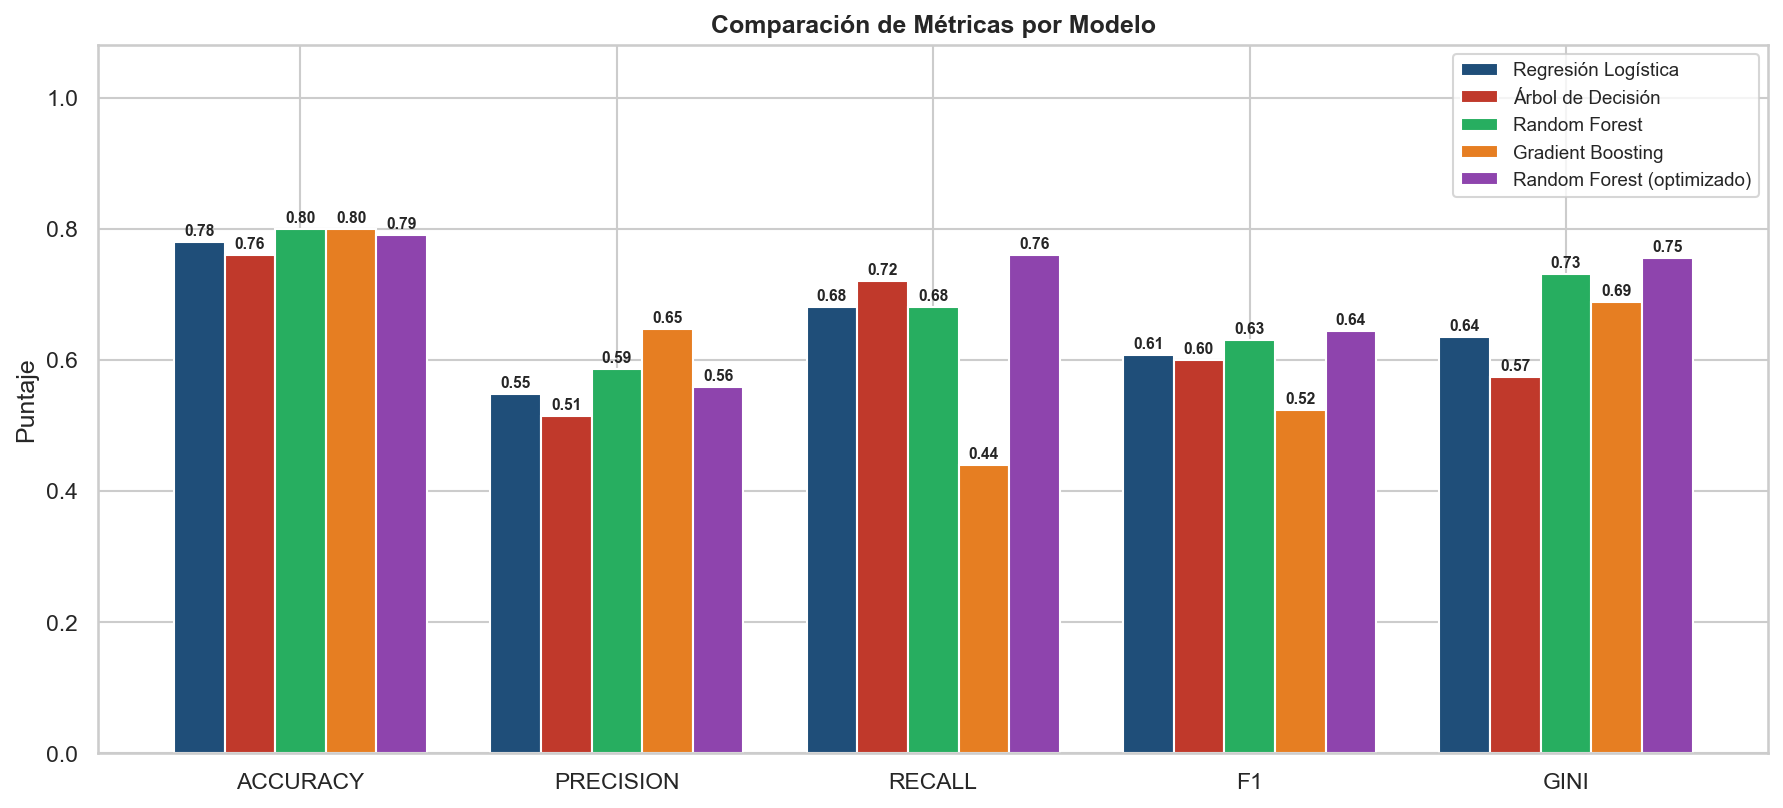

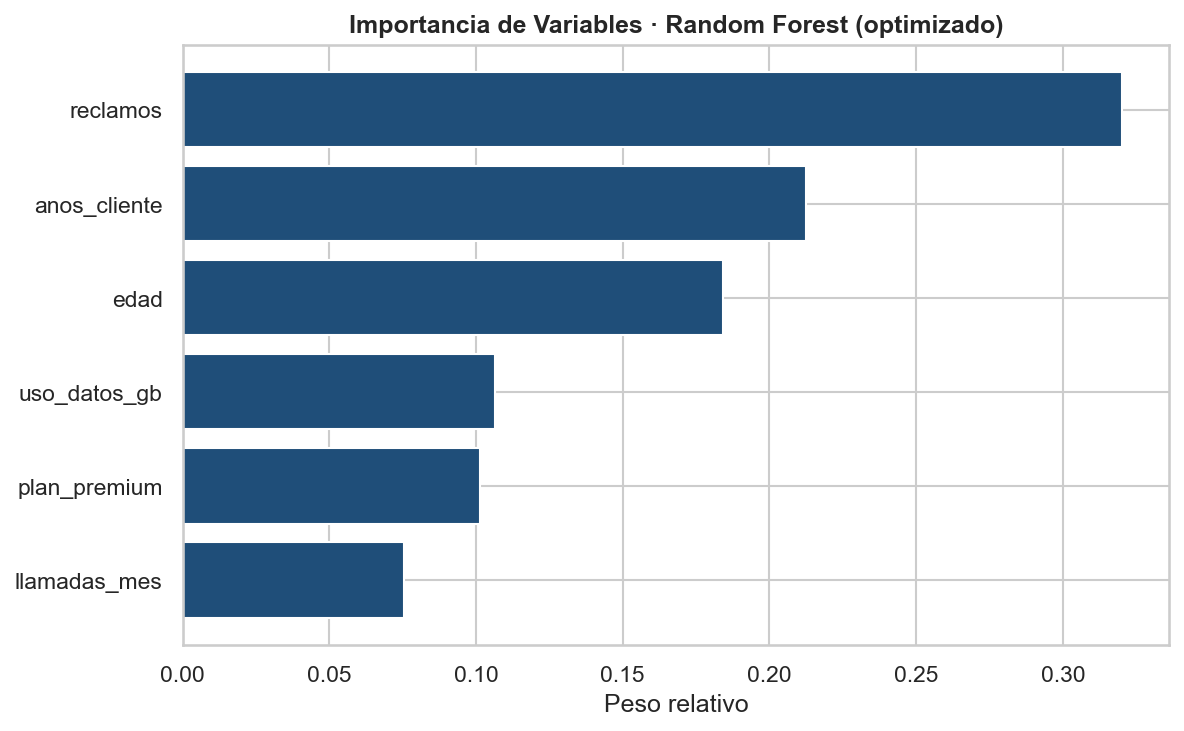

In [8]:
for n in ["05_matriz_confusion", "06_curva_roc", "07_comparacion_metricas", "08_importancia_variables"]:
    display(Image(filename=str(viz.DIR_FIG / f"{n}.png")))

## 💡 Paso 6 — Interpretación y conclusiones

| Métrica | Valor | Lectura |
|---|---|---|
| Recall | 0,76 | Detecta el 76 % de los abandonos reales (prioridad de negocio). |
| Precision | 0,56 | Cuando alerta, acierta el 56 % (falsas alarmas asumibles). |
| F1 | 0,64 | Equilibrio Precision/Recall. |
| **Gini** | **0,755** | Poder discriminante alto (AUC 0,877). |

**Conclusión:** el manejo del desbalance (`class_weight='balanced'`) y el ajuste de
hiperparámetros elevaron el Recall desde ~48 % (línea base) a **76 %**. El modelo
se prioriza por Recall porque el **falso negativo** (perder un cliente sin
detectarlo) es el error más costoso del negocio. La decisión de retención final la
toma un humano (cumplimiento Ley 21.719).